# AirPassengers Time Series Analysis

In [2]:
# Import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


import joblib, warnings 
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Library Loaded')

Library Loaded


In [3]:
# Load Dataset
df = pd.read_csv("../dataset/AirPassengers.csv",header=0,names= ['Month', 'Passengers'])

In [4]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
df.shape

(144, 2)

In [6]:
df.info

<bound method DataFrame.info of        Month  Passengers
0    1949-01         112
1    1949-02         118
2    1949-03         132
3    1949-04         129
4    1949-05         121
..       ...         ...
139  1960-08         606
140  1960-09         508
141  1960-10         461
142  1960-11         390
143  1960-12         432

[144 rows x 2 columns]>

In [7]:
df.describe

<bound method NDFrame.describe of        Month  Passengers
0    1949-01         112
1    1949-02         118
2    1949-03         132
3    1949-04         129
4    1949-05         121
..       ...         ...
139  1960-08         606
140  1960-09         508
141  1960-10         461
142  1960-11         390
143  1960-12         432

[144 rows x 2 columns]>

In [8]:
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Month"] =pd.to_datetime(df['Month'])

In [11]:
df.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [12]:
df.set_index("Month",inplace=True)

In [13]:
df.head(2)

,Passengers
Month,
1949-01-01,112
1949-02-01,118


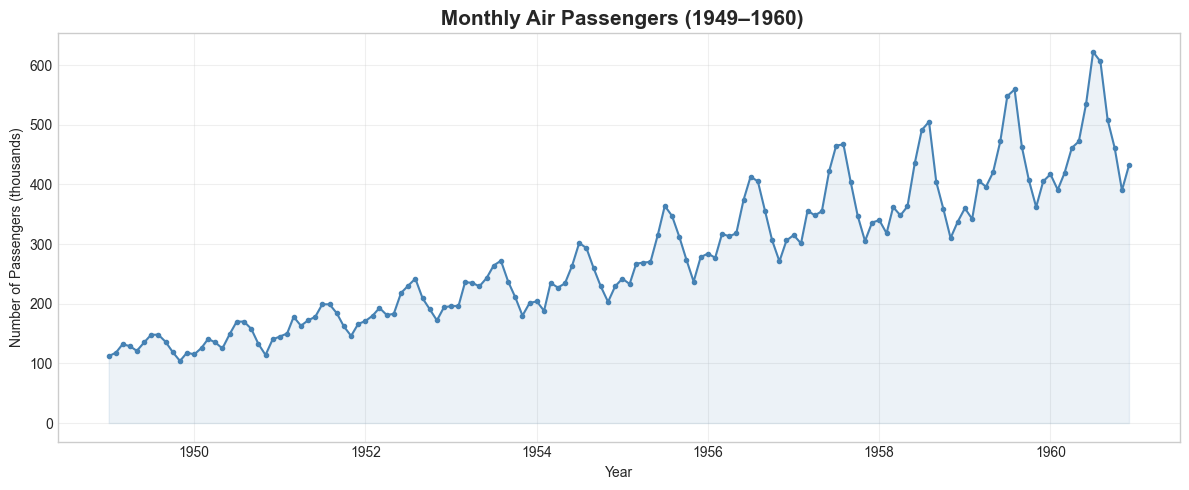

Observation: Clear upward trend + repeating seasonal spikes every year


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df['Passengers'], color='steelblue',  marker='o', markersize=3)
ax.fill_between(df.index, df['Passengers'], alpha=0.1, color='steelblue')

ax.set_title(' Monthly Air Passengers (1949–1960)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Passengers (thousands)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/01_raw_timeseries.png', dpi=150)
plt.show()

print('Observation: Clear upward trend + repeating seasonal spikes every year')

Lets see which months have the highest passengers and how each year looks.

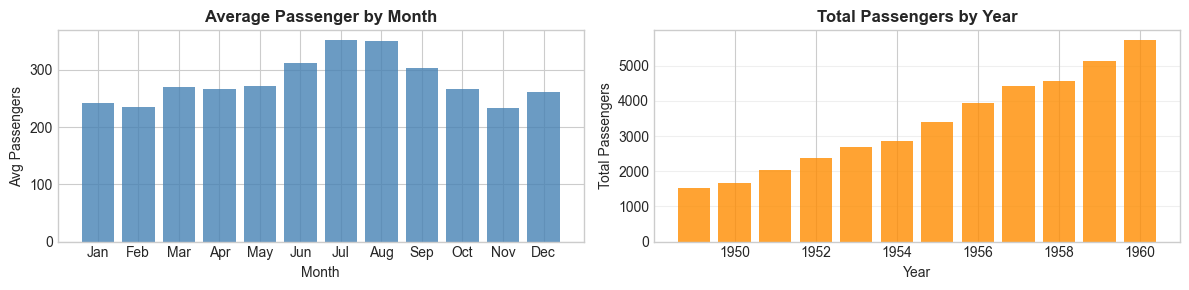

July and August are peak months


In [29]:
# add year and month as separate columns for grouping
df['Year'] = df.index.year
df['Month_Num']  =  df.index.month

# average passengers by month (across all years)
monthly_avg = df.groupby('Month_Num')['Passengers'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1,2, figsize=(12,3))

# left plot: avg per month
axes[0].bar(month_names,monthly_avg.values,color = 'steelblue', alpha=0.8)
axes[0].set_title('Average Passenger by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Passengers')
axes[1].grid(axis='y', alpha=0.3)



# Right plot: total per year
yearly_total = df.groupby('Year')['Passengers'].sum()
axes[1].bar(yearly_total.index,yearly_total.values,color='darkorange', alpha=0.8)
axes[1].set_title('Total Passengers by Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Passengers')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/02_monthly_yearly.png', dpi= 150)
plt.show()

print("July and August are peak months")



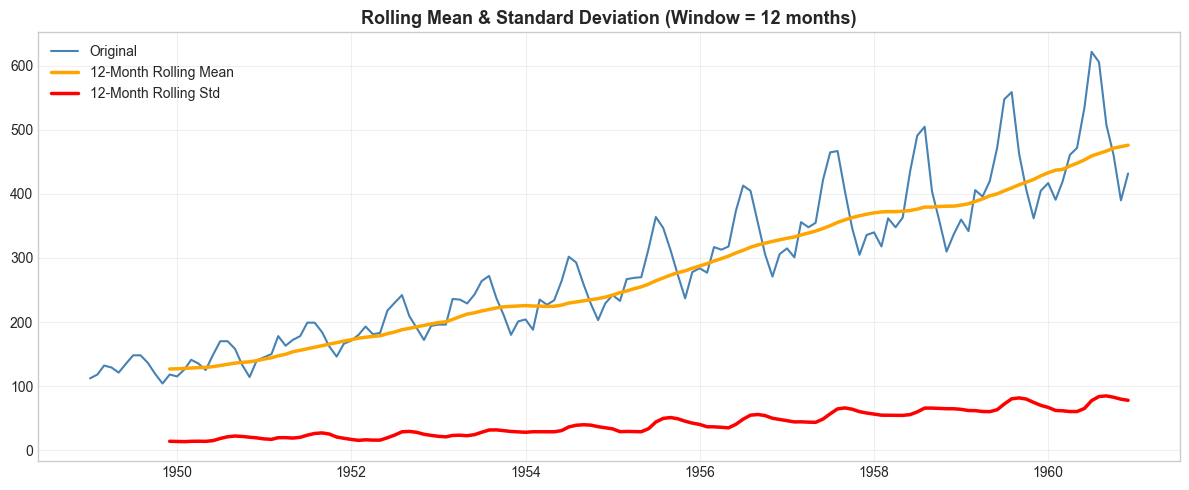

Rolling mean is clearly going up -> series is Non-Stationary


In [31]:
# Calculate 12-month rolling mean and standard deviation
roll_mean = df['Passengers'].rolling(window=12).mean()
roll_std  = df['Passengers'].rolling(window=12).std()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['Passengers'], label='Original',             color='steelblue', linewidth=1.5)
ax.plot(roll_mean,        label='12-Month Rolling Mean', color='orange',    linewidth=2.5)
ax.plot(roll_std,         label='12-Month Rolling Std',  color='red',       linewidth=2.5)

ax.set_title('Rolling Mean & Standard Deviation (Window = 12 months)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/03_rolling_stats.png', dpi=150)
plt.show()

print('Rolling mean is clearly going up -> series is Non-Stationary')